World Cup 2026 Predictor

A ML project that predicts the outcomes of FIFA World Cup 2026 matches and simulates the tournament bracket to crown a predicted winner from player performance data.

The dataset contains per-player, per-match performance statistics (~54,600 rows, 75 features). To predict match outcomes, individual player rows are aggregated up to the team-vs-team match level, then a classifier is trained to predict the result.

In [1]:
!pip install kagglehub
!pip install seaborn
!pip install shap

import os
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">1. Beginning</span>

</div>

In [2]:
import kagglehub
import os

folder = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print(os.listdir(folder))

['goalscorers.csv', 'shootouts.csv', 'results.csv', 'former_names.csv']


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "results.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "martj42/international-football-results-from-1872-to-2017",
    file_path,
)

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">2. Data Splitting</span>

I split the data into 70% training data and 30% test data with random_state = 123

</div>

In [4]:
df['result'] = np.select(
    [df['home_score'] > df['away_score'], df['home_score'] < df['away_score']],
    ['home_win', 'away_win'], default='draw')

train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">3. EDA</span>

I did an exploratory data analysis (EDA) where I conducted an initial exploration of the training set to better understand its characteristics.

Then I summarized the data and included two summary statistics and two visualizations that I found informative and I wrote what insight it provided.

After that, I summarized my initial observations about the dataset based on my EDA.

Lastly, I selected evaluation metrics that's appropriate metrics for assessing model performance and justified my choice.
</div>

In [5]:
print(train_df.shape)
train_df.info()
train_df.head()

print(train_df['date'].min(), "to", train_df['date'].max())
print(train_df['tournament'].nunique(), "tournament types")

(34633, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 34633 entries, 48195 to 15725
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        34633 non-null  object 
 1   home_team   34633 non-null  object 
 2   away_team   34633 non-null  object 
 3   home_score  34603 non-null  float64
 4   away_score  34603 non-null  float64
 5   tournament  34633 non-null  object 
 6   city        34633 non-null  object 
 7   country     34633 non-null  object 
 8   neutral     34633 non-null  bool   
 9   result      34633 non-null  object 
dtypes: bool(1), float64(2), object(7)
memory usage: 2.7+ MB
1872-11-30 to 2026-06-27
198 tournament types


1. The training set has 34633 matches and 9 columns, spanning from 1872 to 2026. Each row is one international match with the two teams, the score, and context (tournament, city, whether it was on neutral ground)

In [6]:
print(train_df['result'].value_counts(normalize=True))

print(train_df[['home_score', 'away_score']].mean())

result
home_win    0.489937
away_win    0.283140
draw        0.226922
Name: proportion, dtype: float64
home_score    1.761957
away_score    1.183828
dtype: float64


2 summary stats: A) Home wins are the most common outcome with 48.9937%, draws the least — showing a clear home-field advantage that the model should be able to learn and B) Home teams score more goals on average than away teams (1.76 vs 1.18 goals).

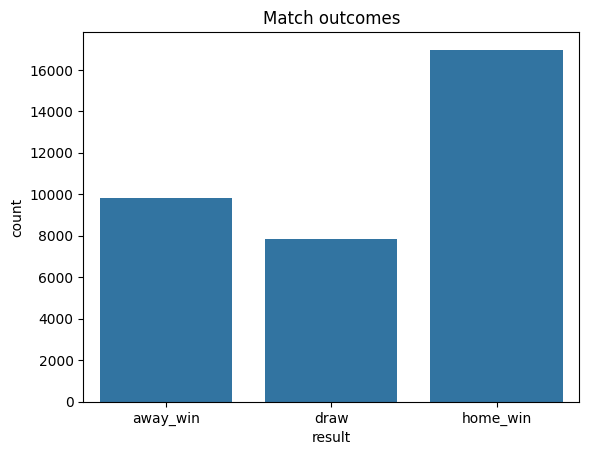

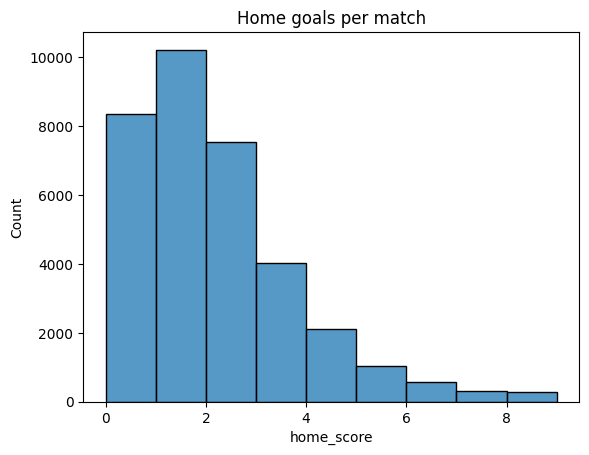

In [7]:
import seaborn as sns, matplotlib.pyplot as plt
sns.countplot(x='result', data=train_df)
plt.title('Match outcomes'); plt.show()

sns.histplot(train_df['home_score'], bins=range(0,10))
plt.title('Home goals per match'); plt.show()

To summarize my findings:
- There's a clear home-field advantage (home wins most common and home teams score more).
- Three outcome classes (home_win / away_win / draw), and they're imbalanced (draws rarest).
- Since the raw data is thin (just has teams, scores, and context), I'll need to engineer features (team strength, recent form) since there's no features like player ratings in the dataset
- Data spans 150+ years; older matches may be less relevant to modern prediction.

This is a 3-class classification problem with imbalanced classes, so:

- I'll use accuracy as a headline number but rely on macro-averaged F1 as the main metric. Because the classes are imbalanced (draws are rare), accuracy can be inflated by always predicting the majority class (home win). Macro-F1 weights all three outcomes equally, so it better reflects whether the model handles draws and away wins too. 
- I'll also compare against a DummyClassifier baseline to confirm the model beats naive guessing

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">4. Feature Engineering</span>

I created new features that are relevant to the problem and use this updated feature later on in my project.

Here's what I did:
1. I split every match into two rows — one from each team's point of view. Now I have a list like "Spain: scored 2, won" / "Canada: scored 0, lost."

2. For each team, I look at their previous 10 matches and average them: win rate, goals scored, goals conceded. I only count games that happened BEFORE the current match (the shift(1)), because in real life you can't know future results when predicting.

3. I attached those numbers back onto the original match. So the Spain-vs-Canada row gets two new sets of columns: Spain's recent form and Canada's recent form.

4. I compare the two teams and the single most useful feature is the difference: Spain's form minus Canada's form. A big positive number = home team much stronger = likely home win. --> Column that does the prediction

</div>

In [8]:
# Work on the FULL df sorted by date, THEN split later (form needs history in order)
df = df.sort_values('date').reset_index(drop=True)

# 1. Reshape to one row per TEAM per match to track each team's history
home = df[['date','home_team','home_score','away_score']].rename(
    columns={'home_team':'team','home_score':'gf','away_score':'ga'})
away = df[['date','away_team','away_score','home_score']].rename(
    columns={'away_team':'team','away_score':'gf','home_score':'ga'})
long = pd.concat([home, away]).sort_values('date')

long['win']    = (long['gf'] > long['ga']).astype(int)
long['points'] = np.select([long.gf > long.ga, long.gf == long.ga], [3, 1], 0)

# 2. Rolling form over each team's PREVIOUS 10 matches (shift(1) = exclude current match)
N = 10
long = long.sort_values(['team','date'])
for col, new in [('win','form_winrate'), ('gf','form_gf'), ('ga','form_ga'), ('points','form_pts')]:
    long[new] = (long.groupby('team')[col]
                     .transform(lambda s: s.shift(1).rolling(N, min_periods=1).mean()))

# 3. Merge each team's form back onto the match (once for home, once for away)
form_cols = ['form_winrate','form_gf','form_ga','form_pts']
form = long[['date','team'] + form_cols]

df = df.merge(form.add_prefix('home_'), left_on=['date','home_team'],
              right_on=['home_date','home_team'], how='left').drop(columns='home_date')
df = df.merge(form.add_prefix('away_'), left_on=['date','away_team'],
              right_on=['away_date','away_team'], how='left').drop(columns='away_date')

# 4. The features that actually predict the winner: the DIFFERENCE in strength
df['winrate_diff'] = df['home_form_winrate'] - df['away_form_winrate']
df['gf_diff']      = df['home_form_gf']      - df['away_form_gf']
df['form_pts_diff']= df['home_form_pts']     - df['away_form_pts']

df[['home_team','away_team','winrate_diff','form_pts_diff','result']].head(15)

,home_team,away_team,winrate_diff,form_pts_diff,result
0,Scotland,England,NaN,NaN,draw
1,England,Scotland,0.000000,0.000000,home_win
2,Scotland,England,-0.500000,-1.500000,home_win
3,England,Scotland,0.000000,0.000000,draw
4,Scotland,England,0.000000,0.000000,home_win
5,Scotland,Wales,NaN,NaN,home_win
6,England,Scotland,-0.300000,-0.833333,away_win
7,Wales,Scotland,-0.571429,-2.000000,away_win
8,Scotland,England,0.458333,1.291667,home_win
9,Scotland,Wales,0.666667,2.222222,home_win


<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">5. Preprocessing and transformations</span>

I identified the feature types in my dataset (e.g., numerical, categorical, ordinal, text) and the transformations you would apply to each type.

I implemented a ColumnTransformer to apply the appropriate preprocessing steps to each feature type.
</div>

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

numerical_features = ['winrate_diff', 'form_pts_diff']

categorical_features = ['home_team', 'away_team'] ## REMOVE RESULT FROM CATEGORICAL FEATURE BC ITS TARGET!!!

preprocessor = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy='mean'), StandardScaler()), numerical_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features),
)

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">6. Baseline Model</span>

I used the DummyClassifier as my basline and this will serve as a reference point for evaluating the performance of my more advanced models later on.

</div>

In [10]:
X_train = train_df.drop(columns=["result"])
y_train = train_df["result"]
X_test  = test_df.drop(columns=["result"])
y_test  = test_df["result"]

train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)

from sklearn.metrics import classification_report
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00      4157
        draw       0.00      0.00      0.00      3428
    home_win       0.49      1.00      0.66      7259

    accuracy                           0.49     14844
   macro avg       0.16      0.33      0.22     14844
weighted avg       0.24      0.49      0.32     14844



/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

My Dummy model is 49% correct when always predicting that home team will win and has an average f1 score of 0.66 

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">7. Linear Models</span>

I trained a linear model as my first real attempt to solving the problem.

I tuned hyperparameters to explore different values of the model's complexity parameter.

I evaluated with cross-validation and summarized my results.

</div>

In [11]:
from sklearn.pipeline import make_pipeline

X = train_df.drop(columns=['result'])
y = train_df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

pipeline = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, random_state=123))

In [12]:
print("winrate_diff present?", 'winrate_diff' in X_train.columns)
print(X_train[['winrate_diff', 'form_pts_diff']].isna().sum())

winrate_diff present? True
winrate_diff     145
form_pts_diff    145
dtype: int64


In [13]:
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

gs = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs.fit(X_train, y_train)

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'logisticregression__C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline', ...), ('onehotencoder', ...)]"


In [14]:
print("Best params:", gs.best_params_)

results = pd.DataFrame(gs.cv_results_)
results = results.sort_values("rank_test_score")

best_std = results.iloc[0]["std_test_score"]

print("Mean CV macro-F1 score:", gs.best_score_)
print("Standard deviation:", best_std)

y_test_pred = gs.predict(X_test)
print(classification_report(y_test, y_test_pred))

Best params: {'logisticregression__C': 100}
Mean CV macro-F1 score: 0.4515464182357614
Standard deviation: 0.00904530919132841
              precision    recall  f1-score   support

    away_win       0.52      0.54      0.53      2963
        draw       0.29      0.06      0.09      2365
    home_win       0.62      0.84      0.71      5134

    accuracy                           0.58     10462
   macro avg       0.48      0.48      0.45     10462
weighted avg       0.52      0.58      0.52     10462



Summary of findings: The mean cross-validation score macro-F1 score is 0.452 ± 0.009, which shows that the model is learning real signal from the team-form features, clearly beating the DummyClassifier baseline (macro-F1 0.22, accuracy 0.49). 

On the validation set it reached 0.58 accuracy and 0.45 macro-F1. The biggest improvement was on away wins (F1 went from 0 to 0.53), which the baseline ignored entirely. The model handles home wins (F1 0.71) and away wins (F1 0.53) well, but struggles with draws (recall 0.06) unsurprising, since draws lack a clear stronger team and are notoriously hard to predict. 

The low standard deviation (±0.009) indicates stable, reliable performance across folds. The optimal C = 100 was the largest value tested, suggesting the model benefits from low regularization; testing higher values could be explored.

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">8. Different Models</span>

I experimented with additional models and trained three models other than a linear model -> I used DecisionTree, RandomForest and GradientBoosting.

I then compared and interpreted results in terms of overfitting/underfitting behavior and fit/score times for each model. 
</div>

In [15]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=123),
    "Random Forest": RandomForestClassifier(random_state=123, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123),
}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    results = cross_validate(pipe, X_train, y_train, cv=5, scoring='f1_macro', return_train_score=True)
    print(f"{name} mean CV macro-F1: {results['test_score'].mean():}")
    print(f"{name} mean train macro-F1: {results['train_score'].mean():}")
    print(f"{name} fit time: {results['fit_time'].mean():} sec\n")

Decision Tree mean CV macro-F1: 0.40502874003415335
Decision Tree mean train macro-F1: 0.9740941010014466
Decision Tree fit time: 0.4321195125579834 sec

Random Forest mean CV macro-F1: 0.42745133881692043
Random Forest mean train macro-F1: 0.973915138006803
Random Forest fit time: 1.231378984451294 sec

Gradient Boosting mean CV macro-F1: 0.3797003775251603
Gradient Boosting mean train macro-F1: 0.3963585430485183
Gradient Boosting fit time: 1.7059579372406006 sec



Findings: The Decision Tree and Random Forest both show strong overfitting with near-perfect train macro-F1 (≈0.97) but much lower test scores (0.41 and 0.43), meaning they memorize the training data. Gradient Boosting did not overfit (train 0.40 ≈ test 0.38) but underfits with default settings, giving the weakest score. 

On fit time, Decision Tree was fastest (0.45s), then Random Forest (1.31s), then Gradient Boosting (slowest, 1.76s). 

None of the tree-based models outperformed the linear model (logistic regression, macro-F1 0.45); Random Forest came closest at 0.427. This suggests the team-form features relate to the outcome in a largely linear way, which the logistic regression captures well. Gradient Boosting could likely improve with hyperparameter tuning (more estimators, greater depth), which I will explore later.

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">9. Feature Selection</span>

I performed feature selection to select relevant features using methods such as RFECV or forward selection.

I then evaluated the impact and compare the model performance before and after feature selection

Lastly, I summarized my findings and decided not to keep feature selection in my pipeline as it does not improve results.
</div>

In [16]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

base_lr = LogisticRegression(max_iter=1000, C=100, random_state=123)

fs_pipe = make_pipeline(
    preprocessor,
    RFECV(estimator=base_lr, step=20, cv=5, scoring='f1_macro', n_jobs=-1),
    LogisticRegression(max_iter=1000, C=100, random_state=123)
)

fs_results = cross_validate(fs_pipe, X_train, y_train, cv=5,
                            scoring='f1_macro', return_train_score=True)

print("Macro-F1 WITHOUT feature selection: 0.452")
print("Macro-F1 WITH feature selection:    %.3f" % fs_results['test_score'].mean())

Macro-F1 WITHOUT feature selection: 0.452
Macro-F1 WITH feature selection:    0.452


In [17]:
fs_pipe.fit(X_train, y_train)
rfecv = fs_pipe.named_steps['rfecv']
print("Optimal number of features:", rfecv.n_features_)
print("Out of total:", len(rfecv.support_))

Optimal number of features: 622
Out of total: 622


I applied RFECV with the logistic regression model. It selected 622 of 622 features, so it kept all of them and macro-F1 was 0.452 with feature selection vs 0.452 without, an identical result. 

Since feature selection did not improve performance, I chose to omit it from the pipeline. This is expected as the two engineered team-form features carry the main signal and aren't redundant, while the one-hot team columns, though individually weak, don't actively harm the model so there's nothing for RFECV to gain by removing them. 

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">10. Hyperparameter Optimization</span>

A) Optimize hyperparameters: Attempt to optimize hyperparameters for the models you have tried so far. In at least one case, tune multiple hyperparameters for a single model.

B) Use suitable optimization methods: You may use any of the following approaches for hyperparameter optimization:
- GridSearchCV
- RandomizedSearchCV
- Bayesian optimization with scikit-optimize

C) Summarize your results: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.
</div>

In [18]:
pipe_rf = make_pipeline(
    preprocessor, RandomForestClassifier(
        n_jobs=-1,
        random_state=123,
    ),
)

pipe_gb = make_pipeline(
    preprocessor, GradientBoostingClassifier(
        random_state=123,
    ),
)

pipe_dt = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=123))

In [19]:
param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [10, 20, None],      # controls overfitting
    'randomforestclassifier__min_samples_leaf': [1, 2, 5],
}

param_grid_gb = {
    'gradientboostingclassifier__n_estimators': [100, 200],
    'gradientboostingclassifier__learning_rate': [0.1, 0.3],  # helps underfitting
    'gradientboostingclassifier__max_depth': [3, 5],
}

param_grid_dt = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, 10, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10, 20],
}

In [20]:
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
gs_rf.fit(X_train, y_train)

gs_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=5, scoring='f1_macro', n_jobs=-1)
gs_gb.fit(X_train, y_train)

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='f1_macro', n_jobs=-1)
gs_dt.fit(X_train, y_train)

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'decisiontreeclassifier__max_depth': [3, 5, ...], 'decisiontreeclassifier__min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline', ...), ('onehotencoder', ...)]"


In [21]:
print("Logistic Regression (from before): 0.452\n")

for name, gs in [("Decision Tree", gs_dt),
                 ("Random Forest", gs_rf),
                 ("Gradient Boosting", gs_gb)]:
    print(f"{name}")
    print(f"  best macro-F1: {gs.best_score_:.3f}")
    print(f"  best params  : {gs.best_params_}\n")

Logistic Regression (from before): 0.452

Decision Tree
  best macro-F1: 0.405
  best params  : {'decisiontreeclassifier__max_depth': None, 'decisiontreeclassifier__min_samples_split': 10}

Random Forest
  best macro-F1: 0.428
  best params  : {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Gradient Boosting
  best macro-F1: 0.429
  best params  : {'gradientboostingclassifier__learning_rate': 0.3, 'gradientboostingclassifier__max_depth': 5, 'gradientboostingclassifier__n_estimators': 200}



Hyperparameter tuning improved Gradient Boosting substantially (0.38 → 0.43), confirming it had been underfitting. The best parameters (learning_rate 0.3, max_depth 5, 200 trees) were all at the high-capacity end of the grid. Random Forest (0.427 → 0.428) and Decision Tree (0.405 → 0.405) saw negligible change; notably, Random Forest's tuning preferred max_depth=None, meaning constraining depth did not help. 

Despite tuning, no tree-based model surpassed logistic regression's 0.452 and the best tuned tree reached only 0.429. This reinforces that the relationship between the team-form features and match outcome is largely linear, which the logistic regression captures most effectively. I therefore carry logistic regression (C=100) forward as my final model.

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">11. Interpretation and feature importances</span>

A) Interpret model feature importance: Use one of the interpretation methods discussed in class (e.g., shap), or another suitable method of your choice, to examine the most important features of one of your non-linear models.

B) Summarize insights: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.
</div>

In [22]:
best_rf = gs_rf.best_estimator_                 
rf_model = best_rf.named_steps['randomforestclassifier']
prep     = best_rf.named_steps['columntransformer']

feature_names = prep.get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

print(importances.sort_values(ascending=False).head(15))

pipeline__form_pts_diff                   0.162518
pipeline__winrate_diff                    0.089584
onehotencoder__home_team_Mexico           0.004269
onehotencoder__home_team_France           0.004015
onehotencoder__home_team_Netherlands      0.003781
onehotencoder__home_team_Sweden           0.003745
onehotencoder__home_team_Austria          0.003688
onehotencoder__home_team_Japan            0.003669
onehotencoder__home_team_Switzerland      0.003647
onehotencoder__home_team_United States    0.003540
onehotencoder__home_team_Poland           0.003487
onehotencoder__home_team_Belgium          0.003468
onehotencoder__away_team_Hungary          0.003429
onehotencoder__away_team_Sweden           0.003356
onehotencoder__home_team_South Korea      0.003348
dtype: float64


pipeline__form_pts_diff                   0.162518
pipeline__winrate_diff                    0.089584
onehotencoder__home_team_Mexico           0.004269
onehotencoder__home_team_France           0.004015
onehotencoder__home_team_Netherlands      0.003781
onehotencoder__home_team_Sweden           0.003745
onehotencoder__home_team_Austria          0.003688
onehotencoder__home_team_Japan            0.003669
onehotencoder__home_team_Switzerland      0.003647
onehotencoder__home_team_United States    0.003540
dtype: float64


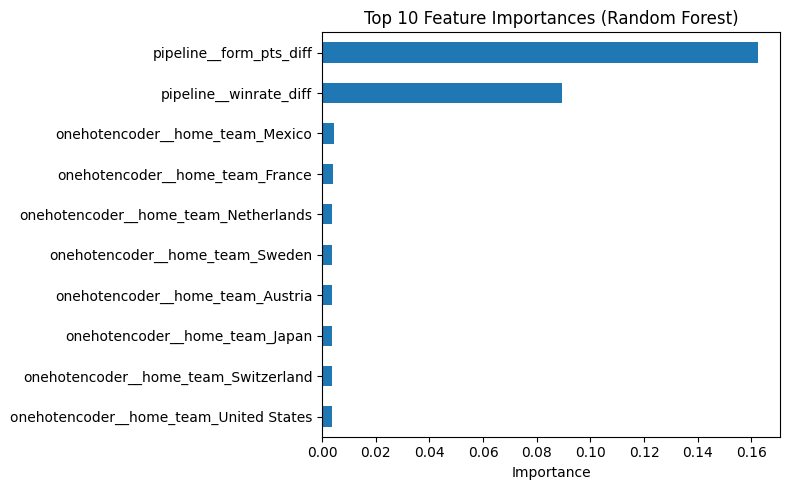

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = gs_rf.best_estimator_
rf_model = best_rf.named_steps['randomforestclassifier']
prep     = best_rf.named_steps['columntransformer']

feature_names = prep.get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

top = importances.sort_values(ascending=False).head(10)
print(top)

# Clean horizontal bar chart
top.sort_values().plot.barh(figsize=(8, 5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">12. Results on the test set</span>

A) Evaluate on the test set: Apply your best-performing model to the test data and report the test scores.

B) Compare and reflect: Compare the test scores with the validation scores from previous experiments. Discuss the consistency between them. How much do you trust your results? Reflect on whether you might have encountered optimization bias.

C) Explain individual predictions: Select one or two examples from your test predictions and use an interpretation method (e.g., SHAP force plots) to explain these individual predictions.
</div>

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

final_model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, C=100, random_state=123)
)
final_model.fit(X_train, y_train)

X_test_final = test_df.drop(columns=['result'])
y_test_final = test_df['result']

y_pred = final_model.predict(X_test_final)

print(classification_report(y_test_final, y_pred))
print("Test macro-F1: %.3f" % f1_score(y_test_final, y_pred, average='macro'))

              precision    recall  f1-score   support

    away_win       0.53      0.55      0.54      4194
        draw       0.30      0.07      0.11      3372
    home_win       0.62      0.83      0.71      7380

    accuracy                           0.58     14946
   macro avg       0.48      0.48      0.45     14946
weighted avg       0.52      0.58      0.52     14946

Test macro-F1: 0.451


The final logistic regression achieved a test macro-F1 of 0.451 and accuracy of 0.58, nearly identical to the cross-validation macro-F1 of 0.452. This very close agreement indicates the model generalizes well and the validation estimate was reliable. Although choosing C via cross-validation introduces some optimization bias (making 0.452 slightly optimistic), the held-out test set — untouched during all training and tuning — gives an unbiased estimate, and its agreement with the CV score (within 0.001) shows the bias was negligible. Combined with the low CV standard deviation (±0.009), I trust these results. As in earlier experiments, draws remain the hardest class (F1 0.11, recall 0.07) — the model rarely predicts them — while home and away wins are handled well (F1 0.71 and 0.54). This is expected, since draws lack a clearly stronger team for the form features to distinguish.

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">13. Summary</span>

A) Summarize key results: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

B) Write concluding remarks: Summarize your main takeaways from the project, including what worked well and what did not.

C) Propose future improvements: Discuss ideas or approaches you did not try but that could potentially improve performance or interpretability.

Report final results: Report your final test score and the metric you used.
</div>